# **Прогнозирование заработной платы сотрудников**

## **Постановка задач**

**Бизнес-постановка задачи:**

Компании сталкиваются с необходимостью предлагать конкурентоспособные зарплаты, чтобы привлекать талантливых сотрудников, но при этом избегать необоснованного завышения бюджета фонда оплаты труда. Решение этой проблемы заключается в **разработке предиктивной модели, которая на основе данных о сотрудниках и характеристиках рабочих мест будет прогнозировать рыночно обоснованную зарплату** для новых кандидатов. Внедрение такого инструмента позволит HR-специалистам и руководителям принимать обоснованные решения по оплате труда и сократить субъективизм при назначении зарплат.


**Постановка ML-задачи:**

В рамках данного проекта реализуется ML-задача **множественной регрессии**. На вход модели подаются признаки, характеризующие профиль сотрудника и условия работы, которые включают в себя как категориальные, так и числовые переменные. На выходе модель предсказывает целевую переменную - годовую зарплату в долларах США.

## **Метрики для измерения качества**

**Для оценки качества регрессионной модели** прогнозирования заработной платы **воспользуемся MAE в качестве основной метрики и коэффициентом детерминации в качестве дополнительной**. Так как целевая переменная (годовая зарплата) может иметь асимметричное распределение и содержать выбросы, то выбор MAE, которая менее чувствительна к выбросам по сравнению с RMSE, позволяет получить более устойчивую и не завышенную оценку ошибки. Помимо этого, MAE выражает ошибку в абсолютных денежных единицах (долларах США), что упрощает интерпретацию результата. Коэффициент детерминации дополняет оценку: он показывает, какая доля дисперсии зарплат объясняется построенной моделью, и позволяет сравнить её качество с простейшим константным прогнозом - предсказанием среднего значения.

## **Знакомство с данными**

Загрузка датасета с Kaggle

In [1]:
%pip install opendatasets
import opendatasets as od
import pandas as pd

od.download("https://www.kaggle.com/datasets/algozee/employee-salary-prediction-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: belozerovaolga
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/algozee/employee-salary-prediction-dataset


100%|██████████| 3.00M/3.00M [00:00<00:00, 94.9MB/s]

In [2]:
df = pd.read_csv("/content/employee-salary-prediction-dataset/job_salary_prediction_dataset.csv")

Вывод первых 5 строк датасета для ознакомления с его структурой

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


Вывод размерности датасета (количество строк и столбцов)

In [4]:
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размерность датасета: 250000 строк, 10 столбцов


**Вывод:** Датасет содержит 250 000 записей, что является достаточным объемом для построения регрессионной модели.

Таблица с информацией о столбцах: тип данных, количество пропущенных значений, число уникальных значений

In [5]:
info_df = pd.DataFrame({
    "Тип данных": df.dtypes,
    "Количество пропусков": df.isnull().sum(),
    "Количество уникальных значений": df.nunique()
})

info_df

,Тип данных,Количество пропусков,Количество уникальных значений
job_title,object,0,12
experience_years,int64,0,21
education_level,object,0,5
skills_count,int64,0,19
industry,object,0,10
company_size,object,0,5
location,object,0,10
remote_work,object,0,3
certifications,int64,0,6
salary,int64,0,118956


**Вывод:** **Во всех столбцах отсутствуют пропущенные значения**, что избавляет от необходимости обработки пропусков. Среди признаков представлены как числовые переменные, так и категориальные, которые можно разделить на номинальные и порядковые. Такое разнообразие типов категориальных признаков, а также различие в количестве уникальных значений, требует применения разных подходов к кодированию.

## **Описание датасета** "Прогнозирование заработной платы сотрудников" (Employee Salary Prediction Dataset)

Датасет содержит 250 000 строк и 10 столбцов.

Датасет включает информацию о профилях сотрудников и характеристиках их рабочих мест, предназначенную для прогнозирования заработной платы на рынке труда. Каждая строка представляет собой запись о сотруднике с указанием его должности, уровня квалификации, уровня образования, отраслевой принадлежности и условий труда, а также целевой переменной - годовой зарплаты.


Описание переменных датасета:

1) job_title (object): название должности сотрудника

2) experience_years (int64): стаж работы сотрудника

3) education_level (object): наивысший достигнутый уровень образования сотрудника

4) skills_count (int64): количество профессиональных навыков, которыми владеет сотрудник

5) industry (object): отрасль, в которой работает сотрудник

6) company_size (object): категория размера компании (например, малая, средняя, крупная)

7) location (object): географическое расположение места работы

8) remote_work (object): формат работы (удалённая, офисная, гибридная)

9) certifications (int64): количество профессиональных сертификатов, которыми обладает сотрудник

10) salary (int64): целевая переменная, годовая зарплата сотрудника в долларах США




### **Проверка наличия полных дубликатов записей** (по всем столбцам)

In [6]:
# Вывод количества строк, которые являются повторами других строк
print(f"Количество строк‑дубликатов (полностью идентичных): {df.duplicated().sum()}")

Количество строк‑дубликатов (полностью идентичных): 0


### **Проверка наличия конфликтующих записей**: одинаковые признаки, но разная целевая переменная

In [7]:
# Формируем список столбцов-признаков, исключая целевую переменную salary
features = df.columns.drop('salary').tolist()

# Группируем строки по всем признакам и подсчитываем количество уникальных значений зарплаты в каждой группе
grouped = df.groupby(features)
salary_variability = grouped['salary'].nunique()

# Отбираем только те группы, где на один и тот же набор признаков приходится более одной уникальной зарплаты
inconsistent_groups = salary_variability[salary_variability > 1]

# Выводим количество групп, в которых одинаковый набор признаков сочетается с разными значениями зарплаты
print(f"Количество групп с одинаковыми признаками и разными зарплатами: {len(inconsistent_groups)}")

Количество групп с одинаковыми признаками и разными зарплатами: 140


**Вывод:** **Обнаружено 140 групп записей, в которых один и тот же набор признаков соответствует разным значениям целевой переменной**. Такая неоднозначность разметки является проблемой для обучения модели: наличие нескольких вариантов зарплаты при идентичных признаках вносит противоречия в данные, что может привести к ухудшению качества модели, увеличению ошибки прогноза и снижению её способности к обобщению.

Для более детального понимания масштаба проблемы и принятия обоснованного решения о дальнейшей обработке данных проведем углубленный анализ конфликтующих групп: определим, сколько строк входит в каждую группу, сколько уникальных значений зарплаты в ней представлено и насколько сильно эти значения различаются между собой.

In [8]:
# Детальный анализ конфликтующих групп с одинаковыми признаками и разными зарплатами

# Детальный вывод по каждой конфликтующей группе
for i, group_values in enumerate(inconsistent_groups.index, start=1):
    # Получаем все строки текущей группы
    group_rows = grouped.get_group(group_values)

    # Размер группы (сколько строк с одинаковыми признаками)
    n_rows = len(group_rows)

    # Уникальные значения зарплаты в группе
    unique_salaries = group_rows['salary'].unique()
    unique_salaries = sorted([int(sal) for sal in unique_salaries])

    # Вывод информации о группе
    print(f"\nГруппа {i}:")
    print(f"  Число строк в группе: {n_rows}")
    print(f"  Количество уникальных зарплат: {len(unique_salaries)}")
    print(f"  Значения признаков:")
    for feature, value in zip(features, group_values):
        print(f"    {feature}: {value}")
    print(f"  Уникальные значения зарплаты: {unique_salaries}")


Группа 1:
  Число строк в группе: 2
  Количество уникальных зарплат: 2
  Значения признаков:
    job_title: AI Engineer
    experience_years: 2
    education_level: High School
    skills_count: 9
    industry: Technology
    company_size: Small
    location: Singapore
    remote_work: No
    certifications: 1
  Уникальные значения зарплаты: [113490, 118820]

Группа 2:
  Число строк в группе: 2
  Количество уникальных зарплат: 2
  Значения признаков:
    job_title: AI Engineer
    experience_years: 3
    education_level: PhD
    skills_count: 9
    industry: Finance
    company_size: Small
    location: Australia
    remote_work: No
    certifications: 3
  Уникальные значения зарплаты: [149515, 158530]

Группа 3:
  Число строк в группе: 2
  Количество уникальных зарплат: 2
  Значения признаков:
    job_title: AI Engineer
    experience_years: 4
    education_level: Diploma
    skills_count: 4
    industry: Retail
    company_size: Enterprise
    location: Canada
    remote_work: No
  

**Вывод:** **Во всех 140 группах с одинаковым набором признаков количество уникальных значений зарплаты равно двум**. Это означает, что **для каждого набора признаков встречаются только два варианта годовой зарплаты**.

Оценим, насколько сильно различаются значения зарплаты внутри каждой группы. Если разница в большинстве групп невелика, это может объясняться естественной вариативностью зарплат на рынке труда. Если же присутствуют группы с большими расхождениями, это может свидетельствовать о наличии выбросов или проблем с качеством данных.

Минимальная разница зарплат в группах: 305
Максимальная разница зарплат в группах: 19268
Средняя разница: 5627


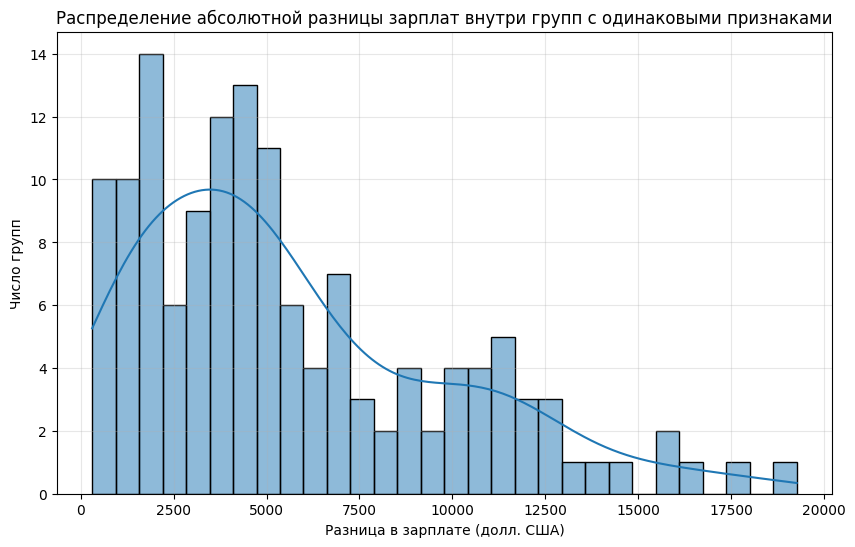

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Список для хранения абсолютных разниц зарплат по группам
salary_diffs = []

# Перебираем все конфликтующие группы
for group_values in inconsistent_groups.index:
    # Получаем все строки текущей группы
    group_rows = grouped.get_group(group_values)
    # Берём две зарплаты и считаем модуль разницы
    salaries = group_rows['salary'].values
    diff = abs(salaries[1] - salaries[0])
    salary_diffs.append(diff)

# Выводим базовую статистику
print(f"Минимальная разница зарплат в группах: {min(salary_diffs):}")
print(f"Максимальная разница зарплат в группах: {max(salary_diffs):}")
print(f"Средняя разница: {round(sum(salary_diffs)/len(salary_diffs)):}")

# Строим гистограмму распределения абсолютной разницы зарплат
plt.figure(figsize=(10, 6))
sns.histplot(salary_diffs, bins=30, kde=True)
plt.title("Распределение абсолютной разницы зарплат внутри групп с одинаковыми признаками")
plt.xlabel("Разница в зарплате (долл. США)")
plt.ylabel("Число групп")
plt.grid(True, alpha=0.3)
plt.show()

**Вывод:** **Распределение абсолютной разницы зарплат внутри групп с одинаковыми признаками имеет ярко выраженную правостороннюю асимметрию** с длинным правым хвостом, что означает: **большинство групп характеризуется относительно небольшой разницей в зарплате**, находящейся в диапазоне до 7000 долларов, при этом **присутствует заметная доля групп, в которых разница достигает значительных величин** - вплоть до 19268 долларов. Такой вид распределения свидетельствует о том, что в большинстве случаев расхождения в зарплате при идентичных признаках являются умеренными и могут объясняться естественной рыночной вариативностью, однако наличие групп с большими разницами указывает на возможное присутствие выбросов или на влияние на размер зарплаты неучтённых факторов, которые не отражены в данном наборе признаков.

**На основе проведённого анализа наиболее корректным решением будет заменить значения зарплаты в каждой конфликтующей группе на среднее арифметическое, оставив по одной строке на группу**. Наличие двух различных значений зарплаты при идентичных признаках вносит противоречия в данные: для одной комбинации признаков модель не может определить единственное целевое значение, что негативно сказывается на качестве обучения модели. Усреднение позволяет сохранить информативность данных, формируя одно репрезентативное значение на основе обоих реальных наблюдений, и обеспечивает однозначное соответствие между признаками и целевой переменной. Простое сохранение всех строк внесло бы противоречивую разметку, увеличивая неопределённость в обучении, тогда как усреднение устраняет эту неоднозначность, сохраняя репрезентативность данных.

Замена зарплат в конфликтующих группах на среднее арифметическое

In [10]:
# Создаём копию исходного датасета для обработки
df_clean = df.copy()

# Для каждой конфликтующей группы заменяем зарплату на среднее значение
for group_values in inconsistent_groups.index:
    # Получаем все строки текущей группы из исходной группировки
    group_rows = grouped.get_group(group_values)

    # Вычисляем среднее значение зарплаты в группе и округляем до целого числа
    mean_salary = int(round(group_rows['salary'].mean()))

    # Находим строки в df_clean, соответствующие данной группе
    group_mask = (df_clean[features] == group_values).all(axis=1)

    # Заменяем зарплату на среднее значение
    df_clean.loc[group_mask, 'salary'] = mean_salary

# Удаляем дубликаты строк с одинаковыми признаками, оставляя по одной записи на группу
df_final = df_clean.drop_duplicates(subset=features, keep='first').reset_index(drop=True)

print(f"Размер обновлённого датасета: {df_final.shape[0]} строк")

Размер обновлённого датасета: 249860 строк


## **Целевая переменная**

Гистограмма распределения целевой переменной

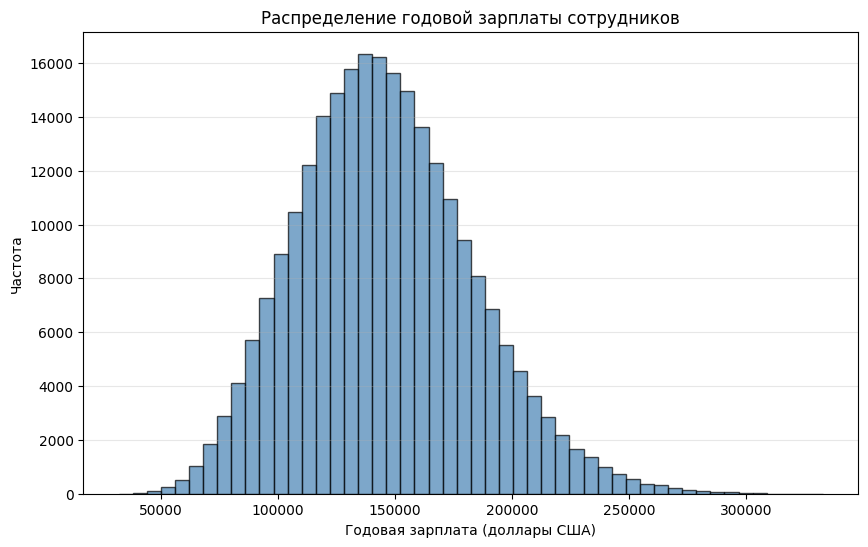

In [11]:
# Гистограмма для визуальной оценки формы распределения зарплат
plt.figure(figsize=(10, 6))
plt.hist(df_final['salary'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Годовая зарплата (доллары США)')
plt.ylabel('Частота')
plt.title('Распределение годовой зарплаты сотрудников')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** **Гистограмма демонстрирует распределение, близкое к нормальному, с легкой правосторонней асимметрией**: пик распределения приходится на диапазон примерно 140 000-150 000 долларов, после чего частота плавно снижается в сторону высоких значений зарплаты, формируя умеренный правый «хвост». Это говорит о том, что основная масса сотрудников сосредоточена вокруг среднего уровня заработной платы, а количество сотрудников с экстремально высокими зарплатами постепенно убывает, что характерно для систем оплаты труда с ограниченным числом высокооплачиваемых позиций.

Сводка описательных статистик целевой переменной

In [12]:
print("Описательные статистики для целевой переменной salary:")
print(df_final['salary'].describe())

Описательные статистики для целевой переменной salary:
count    249860.000000
mean     145713.042492
std       37405.273080
min       31867.000000
25%      119357.750000
50%      143449.500000
75%      169481.000000
max      333046.000000
Name: salary, dtype: float64


**Вывод:** Переменная salary демонстрирует значительный разброс значений (от 31 867 до 333 046 долларов). Анализ квартилей показывает, что 25% сотрудников имеют зарплату не более 119 357,75 долларов, медиана составляет 143 449,50 долларов, а 75% сотрудников получают не более 169 481 доллара.

Boxplot для оценки выбросов

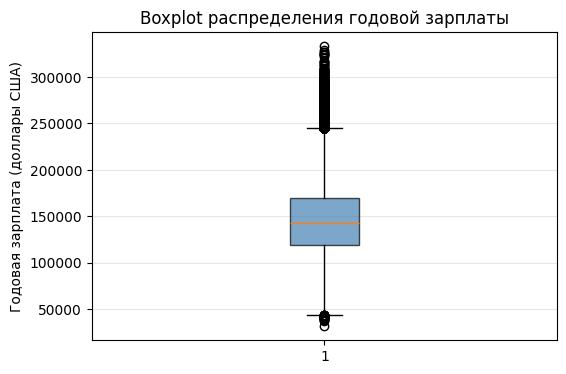

In [13]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_final['salary'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.ylabel('Годовая зарплата (доллары США)')
plt.title('Boxplot распределения годовой зарплаты')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** С точки зрения формального статистического критерия (метод Тьюки) boxplot показывает наличие выбросов в переменной salary. Межквартильный размах сосредоточен в диапазоне примерно от 119 000 до 169 000 долларов, что отражает основную массу сотрудников с типичными для рынка зарплатами. Значения, превышающие верхнюю границу «усов», а также значения, расположенные ниже нижней границы «усов», формально определяются как статистические выбросы. Однако эти «выбросы» соответствуют реальным зарплатам и не являются ошибками или шумом: высокие зарплаты соответствуют реальным доходам высококвалифицированных специалистов, а низкие - могут отражать зарплаты начинающих специалистов. Таким образом, **несмотря на формальное наличие выбросов, их следует оставить в анализе, поскольку они отражают естественное разнообразие зарплат на рынке труда**.

## **Числовые признаки**

Для визуализации распределения дискретных числовых переменных воспользуемся столбчатой диаграммой.

**Анализ переменной experience_years**

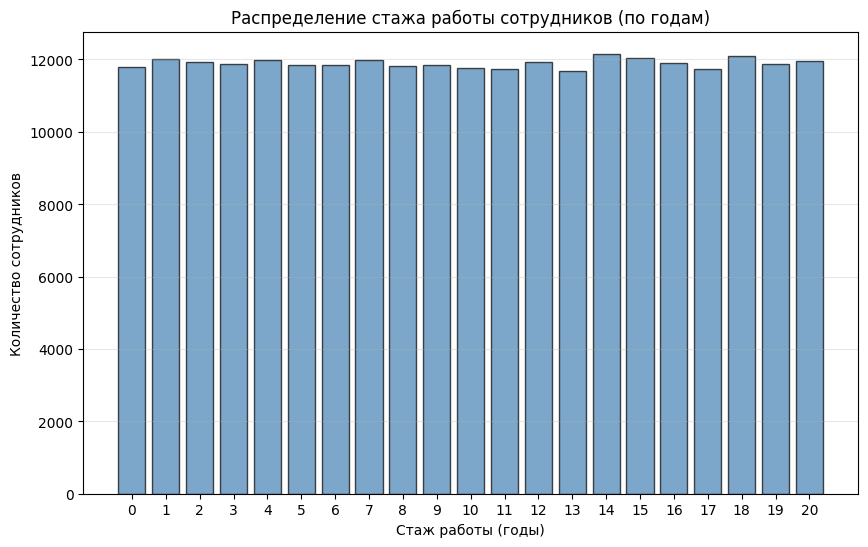

In [14]:
# Столбчатая диаграмма для визуальной оценки формы распределения стажа работы

# Подсчитываем количество сотрудников для каждого значения стажа
experience_counts = df_final['experience_years'].value_counts().sort_index()

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
plt.bar(experience_counts.index, experience_counts.values,
        edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Стаж работы (годы)')
plt.ylabel('Количество сотрудников')
plt.title('Распределение стажа работы сотрудников (по годам)')
plt.xticks(experience_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** **Столбчатая диаграмма распределения стажа работы демонстрирует равномерное распределение**: частота наблюдений для каждого значения от 0 до 20 лет остается стабильной на уровне примерно 12 000 сотрудников, что говорит о сбалансированном представлении сотрудников с разным количеством лет профессионального опыта в датасете. Это означает, что выборка равномерно охватывает все категории специалистов - от начинающих (0 лет опыта) до наиболее опытных (20 лет опыта), что создает благоприятные условия для обучения модели, поскольку она получает достаточное количество примеров для каждого уровня стажа.


In [15]:
# Сводка описательных статистик переменной experience_years
print("Описательные статистики для переменной experience_years:")
print(df_final['experience_years'].describe())

Описательные статистики для переменной experience_years:
count    249860.000000
mean         10.005531
std           6.060717
min           0.000000
25%           5.000000
50%          10.000000
75%          15.000000
max          20.000000
Name: experience_years, dtype: float64


**Вывод:** Переменная experience_years демонстрирует диапазон от 0 до 20 лет. Анализ квартилей показывает, что 25% сотрудников имеют не более 5 лет стажа, медиана составляет 10 лет, а 75% сотрудников имеют не более 15 лет стажа.

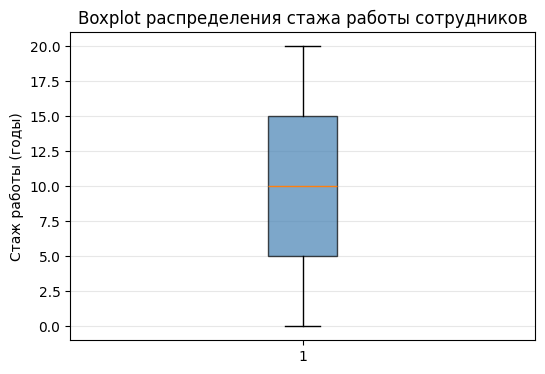

In [16]:
# Boxplot для оценки выбросов
plt.figure(figsize=(6, 4))
plt.boxplot(df_final['experience_years'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.ylabel('Стаж работы (годы)')
plt.title('Boxplot распределения стажа работы сотрудников')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** **Boxplot показывает отсутствие выбросов в переменной experience_years**.

**Анализ переменной skills_count**

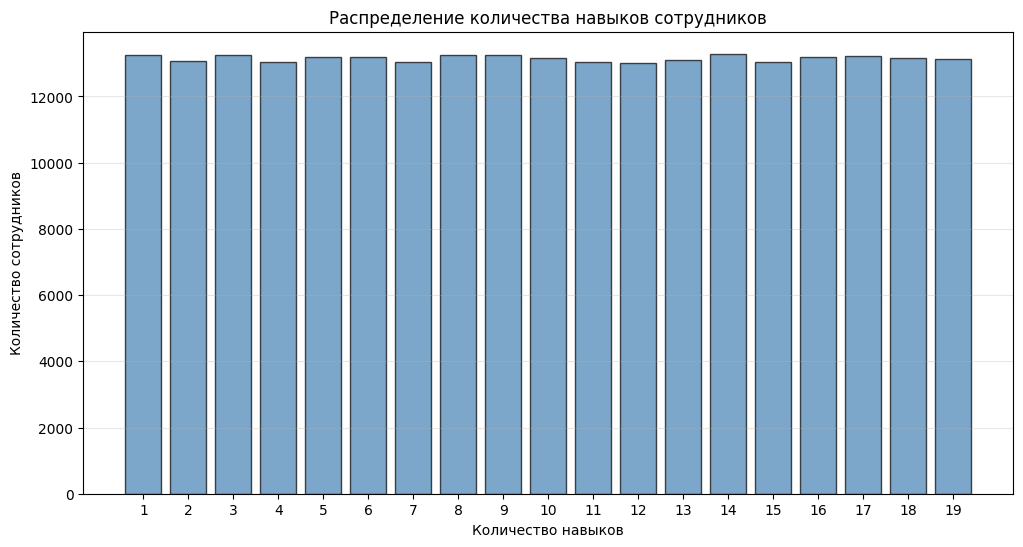

In [17]:
# Столбчатая диаграмма для визуальной оценки формы распределения количества навыков

# Подсчитываем количество сотрудников для каждого значения навыков
skills_counts = df_final['skills_count'].value_counts().sort_index()

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
plt.bar(skills_counts.index, skills_counts.values,
        edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Количество навыков')
plt.ylabel('Количество сотрудников')
plt.title('Распределение количества навыков сотрудников')
plt.xticks(skills_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** **Столбчатая диаграмма распределения количества навыков демонстрирует равномерное распределение**: частота наблюдений для каждого значения от 1 до 19 остается стабильной, что говорит о сбалансированном представлении сотрудников с разным количеством профессиональных навыков в датасете. Это означает, что выборка равномерно охватывает все категории специалистов - от обладающих минимальным набором навыков (1 навык) до высококвалифицированных сотрудников (19 навыков), что создает благоприятные условия для обучения модели, поскольку она получает достаточное количество примеров для каждого значения переменной skills_count.

In [18]:
# Сводка описательных статистик переменной skills_count
print("Описательные статистики для переменной skills_count:")
print(df_final['skills_count'].describe())

Описательные статистики для переменной skills_count:
count    249860.000000
mean          9.998059
std           5.479363
min           1.000000
25%           5.000000
50%          10.000000
75%          15.000000
max          19.000000
Name: skills_count, dtype: float64


**Вывод:** Переменная skills_count демонстрирует диапазон от 1 до 19 навыков. Анализ квартилей показывает, что 25% сотрудников имеют не более 5 навыков, медиана составляет 10 навыков, а 75% сотрудников имеют не более 15 навыков.

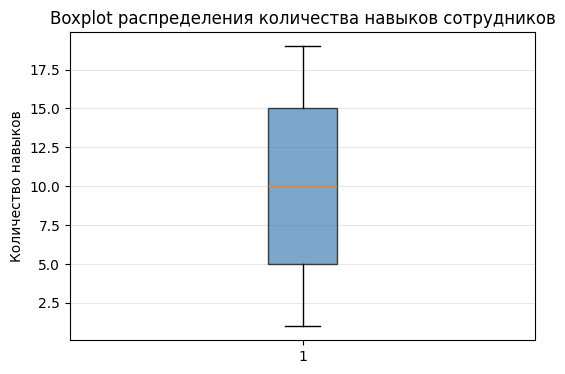

In [19]:
# Boxplot для оценки выбросов
plt.figure(figsize=(6, 4))
plt.boxplot(df_final['skills_count'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.ylabel('Количество навыков')
plt.title('Boxplot распределения количества навыков сотрудников')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** Boxplot показывает **отсутствие выбросов в переменной skills_count**.

**Анализ переменной certifications**

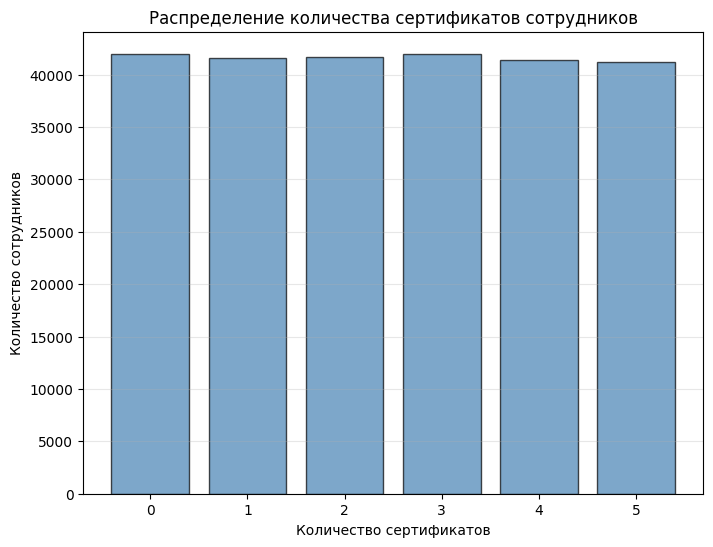

In [20]:
# Столбчатая диаграмма для визуальной оценки формы распределения количества сертификатов

# Подсчитываем количество сотрудников для каждого значения сертификатов
certifications_counts = df_final['certifications'].value_counts().sort_index()

# Строим столбчатую диаграмму
plt.figure(figsize=(8, 6))
plt.bar(certifications_counts.index, certifications_counts.values,
        edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Количество сертификатов')
plt.ylabel('Количество сотрудников')
plt.title('Распределение количества сертификатов сотрудников')
plt.xticks(certifications_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** **Столбчатая диаграмма распределения переменной certifications демонстрирует равномерное распределение**: частота наблюдений для каждого значения от 0 до 5 сертификатов остаётся стабильной, что говорит о сбалансированном представлении сотрудников с разным количеством профессиональных сертификатов в датасете. Это означает, что выборка равномерно охватывает все категории специалистов - от сотрудников без сертификатов (0 сертификатов) до тех, кто имеет большое число сертификатов (5 сертификатов), что создаёт благоприятные условия для обучения модели, поскольку она получает достаточное количество примеров для каждого значения переменной certifications.

In [21]:
# Сводка описательных статистик переменной certifications
print("Описательные статистики для переменной certifications:")
print(df_final['certifications'].describe())

Описательные статистики для переменной certifications:
count    249860.000000
mean          2.491875
std           1.706462
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max           5.000000
Name: certifications, dtype: float64


**Вывод:** Переменная certifications демонстрирует диапазон от 0 до 5 сертификатов. Анализ квартилей показывает, что 25% сотрудников имеют не более 1 сертификата, медиана составляет 2 сертификата, а 75% сотрудников имеют не более 4 сертификатов.

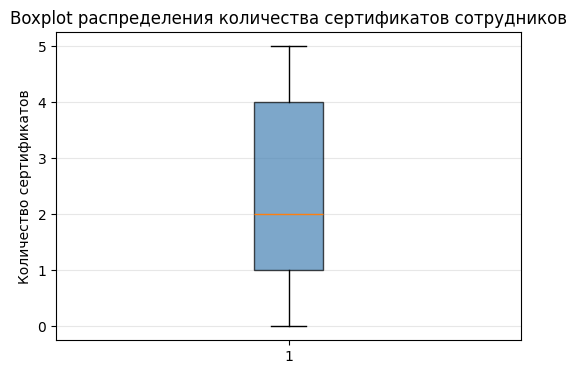

In [22]:
# Boxplot для оценки выбросов
plt.figure(figsize=(6, 4))
plt.boxplot(df_final['certifications'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.ylabel('Количество сертификатов')
plt.title('Boxplot распределения количества сертификатов сотрудников')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод:** Boxplot показывает **отсутствие выбросов в переменной certifications**.

## **Категориальные признаки**

Описательная статистика для категориальных признаков

In [23]:
# Отбираем все столбцы с категориальными данными
cat_cols = df_final.select_dtypes(include='object')

# Применяем describe() для получения сводной статистики по каждой категориальной переменной
cat_cols.describe()

,job_title,education_level,industry,company_size,location,remote_work
count,249860,249860,249860,249860,249860,249860
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21111,50325,25378,50231,25248,83578


**Вывод:** Чаще всего в датасете встречается должность Backend Developer (21 111 наблюдений), уровень образования Master (50 325 наблюдений), финансовая отрасль (Finance) (25 378 наблюдений), крупные компании (Large) (50 231 наблюдение), работа в Австралии (25 248 наблюдений) и офисный режим работы (No) (83 578 наблюдений).

Анализ уникальных значений категориальных переменных и частоты их встречаемости

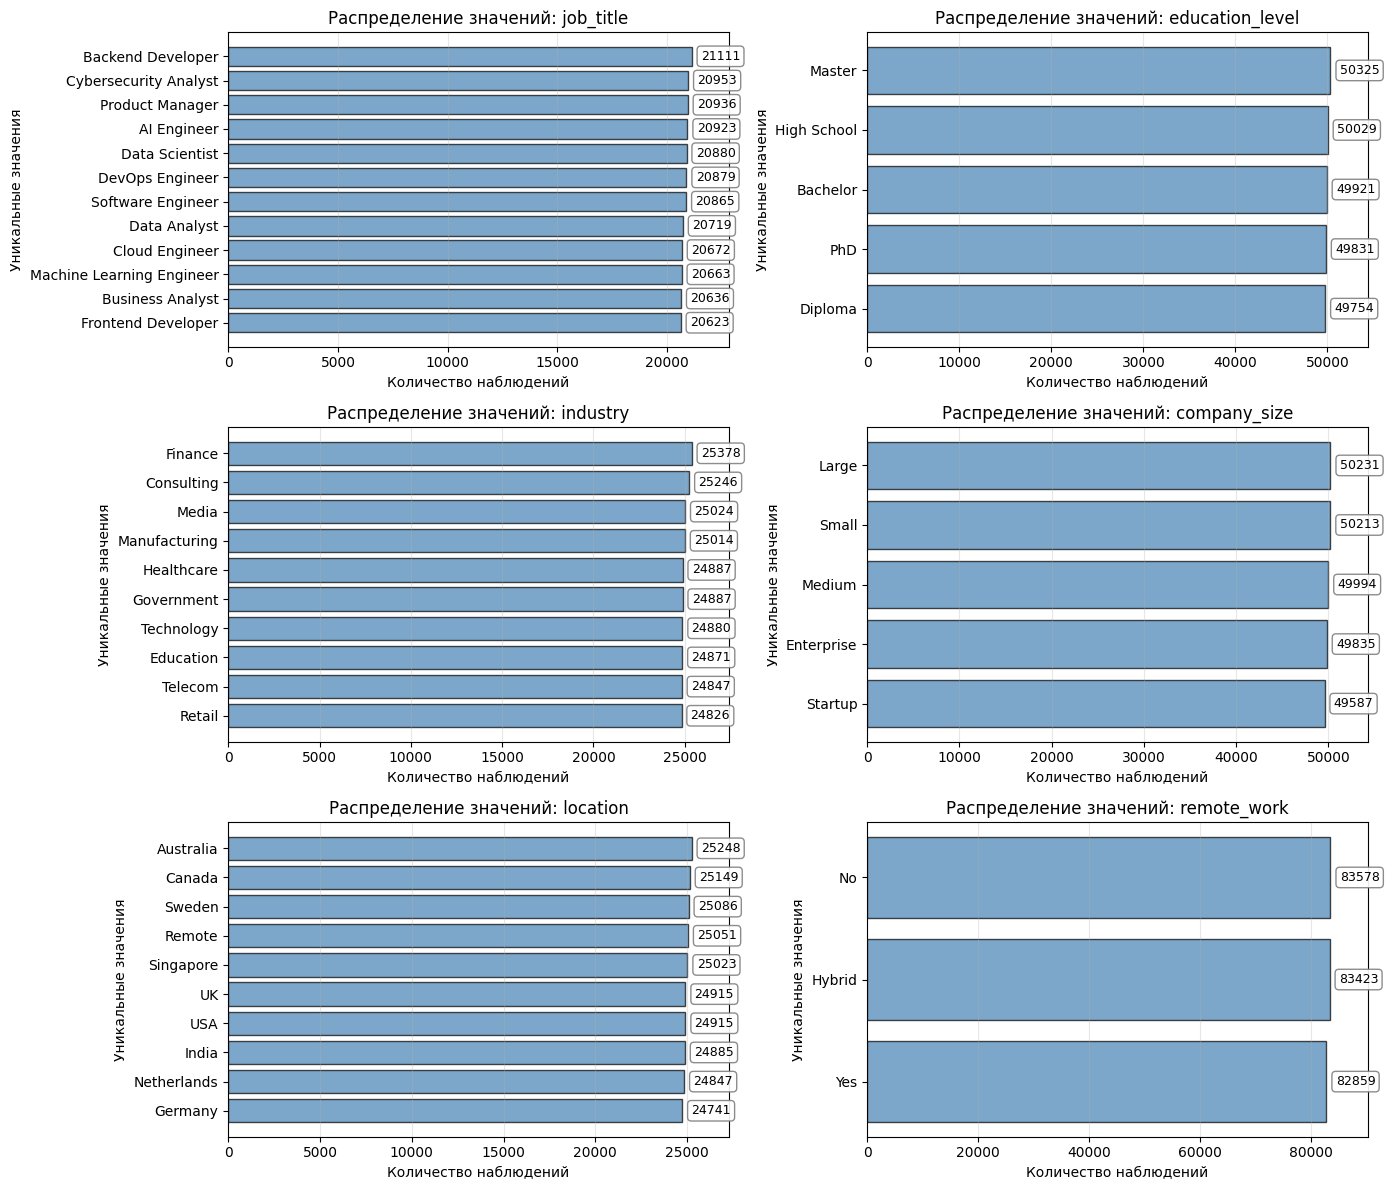

In [24]:
# Столбчатые диаграммы частот уникальных значений категориальных переменных
n_plots = 6
n_cols = 2
n_rows = 3

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Подсчитываем частоту каждого уникального значения
    value_counts = df_final[col].value_counts().sort_values()

    # Строим горизонтальную столбчатую диаграмму
    axes[i].barh(value_counts.index, value_counts.values,
                 edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_xlabel('Количество наблюдений')
    axes[i].set_ylabel('Уникальные значения')
    axes[i].set_title(f'Распределение значений: {col}')
    axes[i].grid(axis='x', alpha=0.3)

    # Добавляем подписи значений на столбцах
    max_count = value_counts.max()

    axes[i].set_xlim(0, max_count * 1.08)

    for idx, (val, count) in enumerate(value_counts.items()):
        x_text = count * 1.02
        axes[i].text(
            x_text, idx, str(count),
            ha='left', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray')
        )
plt.tight_layout()
plt.show()

**Вывод:**

**Распределение уникальных значений во всех категориальных переменных выглядит достаточно равномерным**: наблюдения сбалансированно распределены между категориями, что благоприятно для обучения модели, поскольку она получит достаточное количество примеров по каждой группе, что обеспечит стабильность предсказаний.

Переменная **job_title включает должности, относящиеся исключительно к IT-сфере** (разработчики, аналитики, инженеры, менеджеры продуктов). Это означает, что модель будет предсказывать зарплаты только для IT-специалистов, и её результаты не могут быть обобщены на другие профессиональные сферы.

Переменная **education_level является порядковой, так как уровни образования можно расположить по возрастанию**: High School (среднее общее образование), Diploma (среднее специальное образование), Bachelor (бакалавр), Master (магистр), PhD (докторская степень).

Переменная **industry представлена различными отраслями**, включая финансы, консалтинг, медиа, производство, государственный сектор, здравоохранение, технологии, образование, телекоммуникации и розничную торговлю.

Переменная **company_size также порядковая, поскольку значения выстраиваются по увеличению размера компании**: Startup (стартап), Small (малый бизнес), Medium (средний бизнес), Large (крупный бизнес), Enterprise (корпорация).

**Переменная location** включает названия стран и значение Remote, которое указывает на отсутствие географической привязки к конкретной стране и работу в удалённом формате на глобальном рынке труда, где зарплата ориентирована на международные стандарты, в то время как обычные страны представляют собой национальные рынки труда с привязкой к локальному уровню зарплат. Оставлять это значение целесообразно, поскольку оно несет самостоятельный смысл и позволяет модели учитывать существование глобального рынка труда. Удаление 25 051 записи (10% данных) со значением Remote привело бы к существенной потере информации и искусственному дисбалансу, особенно в переменной remote_work, где количество значений Yes резко уменьшилось бы. Поскольку формат занятости (офисный, гибридный, удаленный) уже учтён в переменной remote_work, оставление Remote в location обеспечивает сохранность данных и возможность учитывать влияние глобального рынка труда.

Переменная **remote_work содержит три формата занятости**: No (**офисный формат**), Hybrid (**гибридный формат**) и Yes (**удалённый формат**). Стилистически можно было бы переименовать столбец в work_mode и значения в Office, Hybrid, Remote, но это не является существенным, поскольку при последующем кодировании переменные всё равно будут преобразованы в числовой формат.

## **Взаимосвязь признаков с целевой переменной**

**Для оценки взаимосвязи между признаками и целевой переменной salary необходимо преобразовать категориальные переменные в числовой формат**. **Поскольку мы находимся на этапе разведочного анализа данных (EDA) и не занимаемся подготовкой данных для итоговой модели, можно использовать простой подход с применением LabelEncoder для всех категориальных признаков**. Это позволит визуализировать на scatter plots потенциальные зависимости между каждой переменной и зарплатой. Важно отметить, что такое кодирование является временным решением только для целей визуализации, а для построения финальной модели будет использован более релевантный подход с учетом порядковой природы некоторых переменных.

Кодировка категориальных переменных для EDA

In [25]:
from sklearn.preprocessing import LabelEncoder

# Создаем копию датасета для EDA, чтобы не изменять исходный df_final
df_eda = df_final.copy()

# Отбираем категориальные столбцы
cat_cols = df_eda.select_dtypes(include=['object']).columns

# Применяем LabelEncoder к каждому категориальному столбцу
le = LabelEncoder()
for col in cat_cols:
    df_eda[col] = le.fit_transform(df_eda[col])

# Проверяем результат преобразования
print(f"\nПервые 5 строк закодированного датасета:")
df_eda.head()


Первые 5 строк закодированного датасета:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,0,10,0,2,4,2,3,0,2,109413
1,5,5,0,17,9,3,0,1,0,93764
2,8,18,4,4,6,2,6,1,1,148123
3,2,19,4,13,7,2,1,2,0,189123
4,10,15,0,7,5,1,7,2,0,165069


Взаимосвязь признаков с целевой переменной

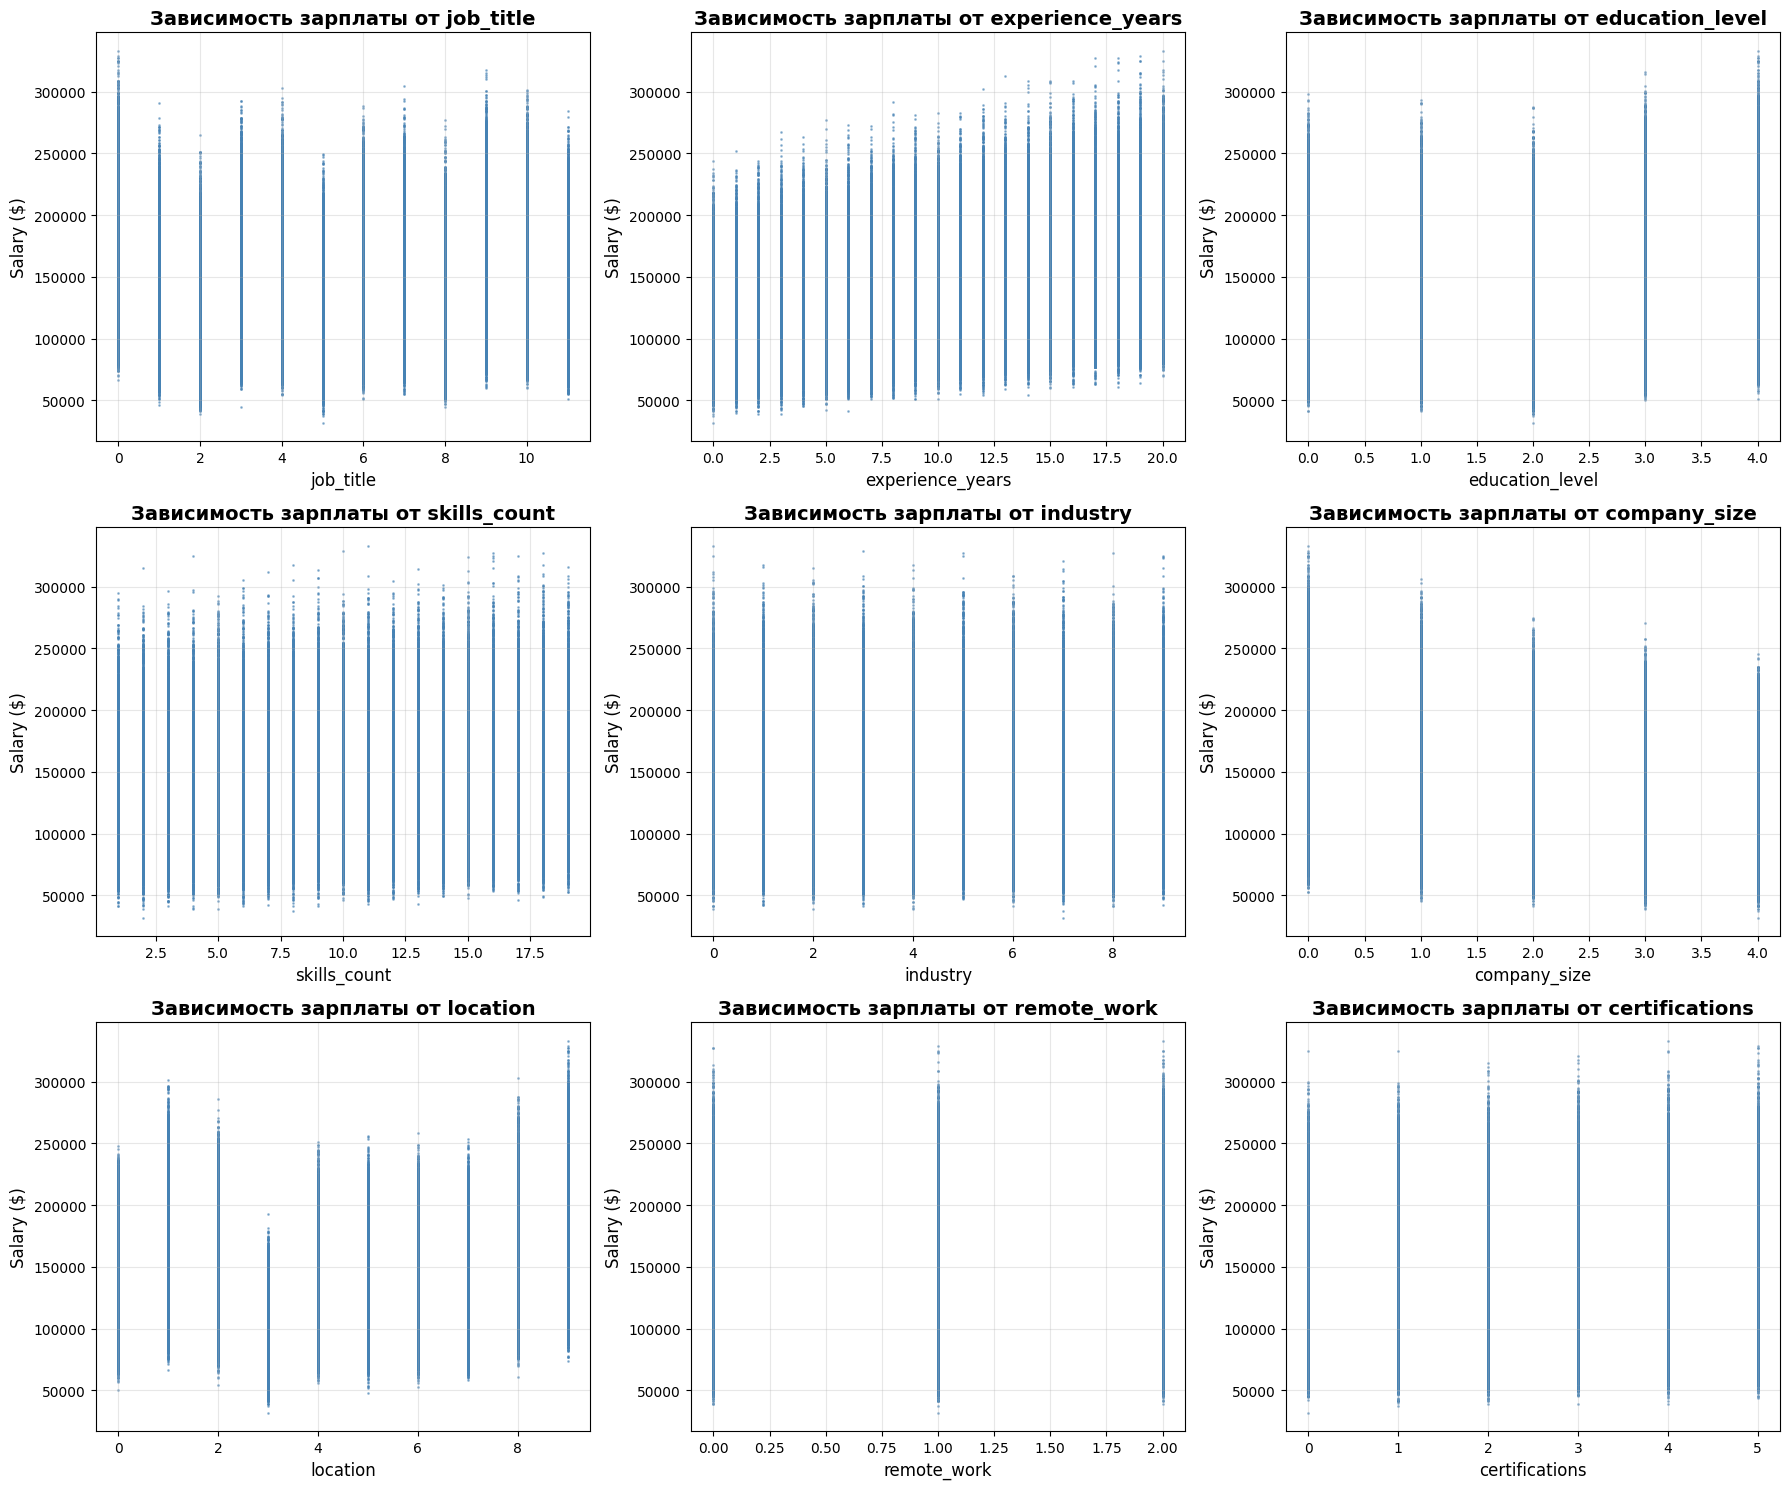

In [26]:
# Определяем количество признаков (исключая целевую переменную salary)
features = df_eda.columns.drop('salary')

# Определяем количество строк и столбцов для подграфиков
n_cols = 3
n_rows = 3

# Создаем фигуру с подграфиками
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Строим scatter plot для каждого признака
for idx, feature in enumerate(features):
    axes[idx].scatter(df_eda[feature], df_eda['salary'], alpha=0.5, s=1, c='steelblue')
    axes[idx].set_xlabel(feature, fontsize=12)
    axes[idx].set_ylabel('Salary ($)', fontsize=12)
    axes[idx].set_title(f'Зависимость зарплаты от {feature}', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:** На основе проведенного визуального анализа Scatter plots можно сделать следующие выводы о характере связи каждого признака с целевой переменной:

**experience_years демонстрирует ярко выраженную положительную связь с зарплатой**: чем больше стаж работы сотрудника, тем выше уровень его годового дохода.

**company_size также показывает сильную положительную связь с целевой переменной**. Поскольку LabelEncoder расположил категории в алфавитном порядке (Enterprise, Large, Medium, Small, Startup), на графике отчетливо видно, что с увеличением размера компании закономерно растет и уровень заработной платы.

**job_title имеет связь с зарплатой**: каждой должности соответствует свой специфический диапазон оплаты труда. При этом наблюдается дифференциация - одни должности характеризуются более высокими стартовыми и максимальными зарплатами, другие - более низкими.

**education_level демонстрирует положительную связь с зарплатой**. Поскольку LabelEncoder расположил категории в алфавитном порядке (Bachelor, Diploma, High School, Master, PhD), на графике отчётливо прослеживается закономерность: наименьшие значения зарплаты соответствуют уровню High School, а наибольшие - PhD. Можно заметить, что по мере повышения уровня образования у сотрудника последовательно возрастает и уровень его оплаты труда.

**location имеет сильно выраженную связь с целевой переменной**: каждое географическое положение характеризуется своим диапазоном зарплат, причем одни локации ассоциируются с более высоким уровнем оплаты, другие — с более низким.

**skills_count демонстрирует слабую положительную связь с зарплатой**: увеличение количества профессиональных навыков в целом сопровождается ростом дохода.

**certifications также показывает слабую положительную связь**: наличие большего числа профессиональных сертификатов соответствует более высокой зарплате.

**industry и remote_work не демонстрируют выраженной связи с зарплатой** - точки на графике распределены без явной структурированной закономерности.


Признаки **experience_years, company_size, education_level и location обладают очень сильной связью с зарплатой**. Это означает, что данные признаки будут играть ключевую роль в прогнозировании и, вероятно, станут наиболее важными для модели, обеспечивая её стабильность и точность. В свою очередь, **skills_count, certifications, industry и remote_work демонстрируют слабую или отсутствующую связь с зарплатой при изолированном рассмотрении**. Однако **это не означает их бесполезность для модели**. В многомерном пространстве **эти переменные могут вступать в важные взаимодействия с другими признаками, раскрывая сложные закономерности, которые не видны при парном анализе**. Поэтому их исключение на этапе подготовки данных может привести к потере значимой информации и снижению качества прогнозов.

## **Корреляция**

**Коэффициент корреляции Пирсона для числовых переменных**

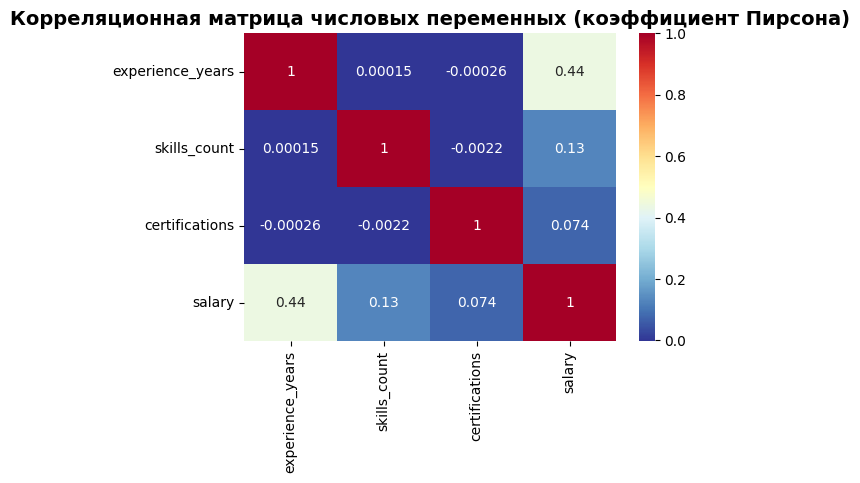

In [27]:
# Отбираем числовые столбцы
num_cols = df_final.select_dtypes(include='int64')

plt.figure(figsize=(6,4))
sns.heatmap(num_cols.corr(), cmap="RdYlBu_r", annot=True)
plt.title('Корреляционная матрица числовых переменных (коэффициент Пирсона)',
          fontsize=14,
          fontweight='bold')
plt.show()

**experience_years (0.44) демонстрирует умеренную положительную корреляцию с зарплатой, что указывает на наличие линейной зависимости**: с увеличением стажа работы доход сотрудника имеет тенденцию к росту.

**skills_count (0,13) и certifications (0,074) показывают** крайне слабую положительную **корреляцию, близкую к нулю**. **Линейная связь практически отсутствует**.

**Корреляции между самими числовыми признаками крайне близки к нулю, что говорит об отсутствии мультиколлинеарности**. Это является благоприятным фактором для построения модели, поскольку признаки практически не дублируют друг друга, каждый из них вносит уникальную, независимую информацию в прогноз.


**Коэффициент корреляции Спирмена для числовых переменных**

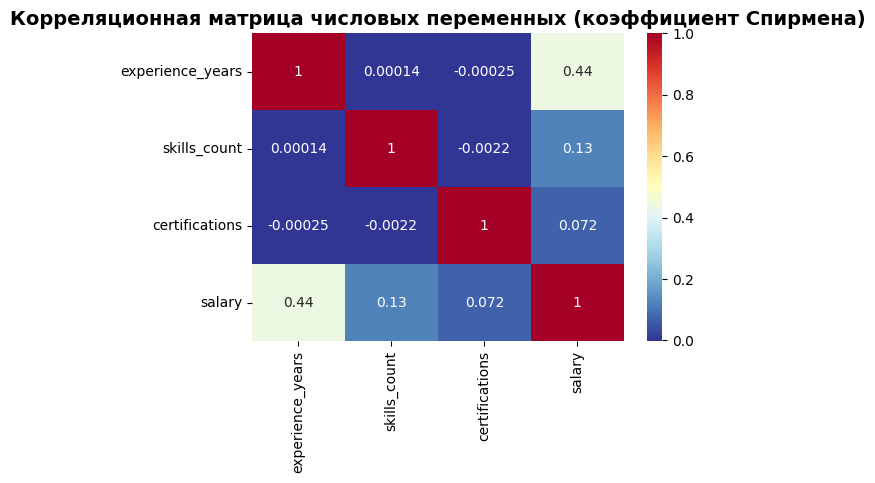

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(num_cols.corr(method='spearman'), cmap="RdYlBu_r", annot=True)
plt.title('Корреляционная матрица числовых переменных (коэффициент Спирмена)',
          fontsize=14,
          fontweight='bold')
plt.show()

Сравнение коэффициентов Пирсона и Спирмена подтверждает, что среди числовых признаков только experience_years демонстрирует умеренную положительную линейную связь с зарплатой, в то время как skills_count и certifications вносят минимальный линейный вклад в прогноз. **Идентичность значений обоих коэффициентов указывает на линейный характер всех выявленных зависимостей**.

**Корреляционный анализ всех переменных с использованием метода Phik**

In [29]:
!pip install phik -q

import phik
from phik.report import plot_correlation_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 28.4 MB/s eta 0:00:00


interval columns not set, guessing: ['experience_years', 'skills_count', 'certifications', 'salary']


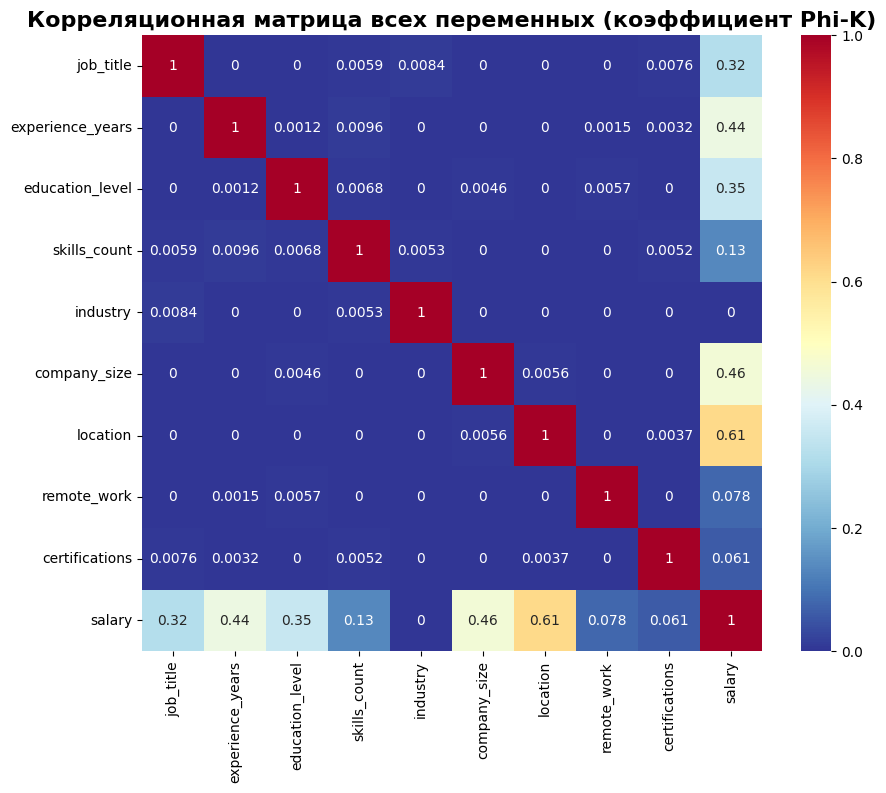

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.phik_matrix(), cmap="RdYlBu_r", annot=True)
plt.title('Корреляционная матрица всех переменных (коэффициент Phi-K)',
          fontsize=16,
          fontweight='bold')
plt.show()

**Вывод:**

**location (0,61) демонстрирует самую сильную связь с зарплатой**. Это означает, что географическое положение является наиболее значимым фактором, определяющим уровень оплаты труда.

Признаки company_size (0,46), experience_years (0,44), education_level (0,35) и job_title (0,32) показывают умеренную положительную связь с зарплатой. Эти переменные отражают традиционные факторы, влияющие на уровень зарплаты: размер компании-работодателя, профессиональный опыт, уровень образования и должностные обязанности

В свою очередь, skills_count (0,13), remote_work (0,078) и certifications (0,061) показывают крайне слабую связь с зарплатой при изолированном рассмотрении, а industry (0,00) демонстрирует нулевую корреляцию, что может указывать на то, что в данном датасете отраслевая принадлежность сама по себе не определяет уровень оплаты труда.

Таким образом, **наиболее информативными признаками для прогнозирования зарплаты являются location, company_size, experience_years, education_level и job_title, которые должны стать основой для построения прогнозной модели**. При этом skills_count, remote_work и certifications, несмотря на слабую индивидуальную связь с целевой переменной, не подлежат исключению, поскольку в сочетании с другими признаками они могут раскрывать важные взаимодействия.

Важно отметить, что все значения корреляций между самими признаками крайне близки к нулю, что свидетельствует об отсутствии мультиколлинеарности.



**Удаление переменной industry**

**Учитывая, что industry демонстрирует нулевую корреляцию как с целевой переменной, так и с остальными признаками, и при этом содержит 10 уникальных категорий, целесообразно исключить эту переменную из набора признаков**. Это решение позволит сократить размерность пространства признаков, снизить риск переобучения и упростить модель без потери предсказательной способности.

In [31]:
df_final.drop('industry', axis=1, inplace=True)

# Проверяем, что столбец был удален
print(f"Новая размерность датасета: {df_final.shape[1]} столбцов")

Новая размерность датасета: 9 столбцов


### **Сохранение датасета**

In [39]:
# 1. Сохраняем датасет в Colab
file_name = 'employee_salary_data_clean.csv'
df_final.to_csv(file_name, index=False, encoding='utf-8')

# 2. Скачиваем файл на локальный компьютер
from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>